In [1]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
import math
from sklearn.linear_model import LogisticRegression
def score_dataset(X, y, model = LogisticRegression(C=0.01, penalty="l2",
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)):
    score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    print(score.mean())
def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings

In [2]:
rain_file_path = 'data/train2_1.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "data/test.csv"
test_data = pd.read_csv(test_file_path)

In [3]:
test_data.fillna(value=160, inplace=True)
X_test = test_data

In [4]:
rain_data

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,1
1,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1
2,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1
3,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1
4,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1
...,...,...,...,...,...,...,...,...,...,...,...
2551,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1
2552,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1
2553,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1
2554,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1


In [5]:
rain_data["year"] = (rain_data.index + 1) / 365
rain_data["year"] = np.ceil(rain_data.year)
rain_data = rain_data.astype({'year': 'int64'})

In [6]:
rain_data.dtypes

pressure         float64
maxtemp          float64
temparature      float64
mintemp          float64
dewpoint         float64
humidity         float64
cloud            float64
sunshine         float64
winddirection    float64
windspeed        float64
rainfall           int64
year               int64
dtype: object

In [7]:
rain_data.year = rain_data.year.replace(8, 7)

<Axes: xlabel='year', ylabel='mintemp'>

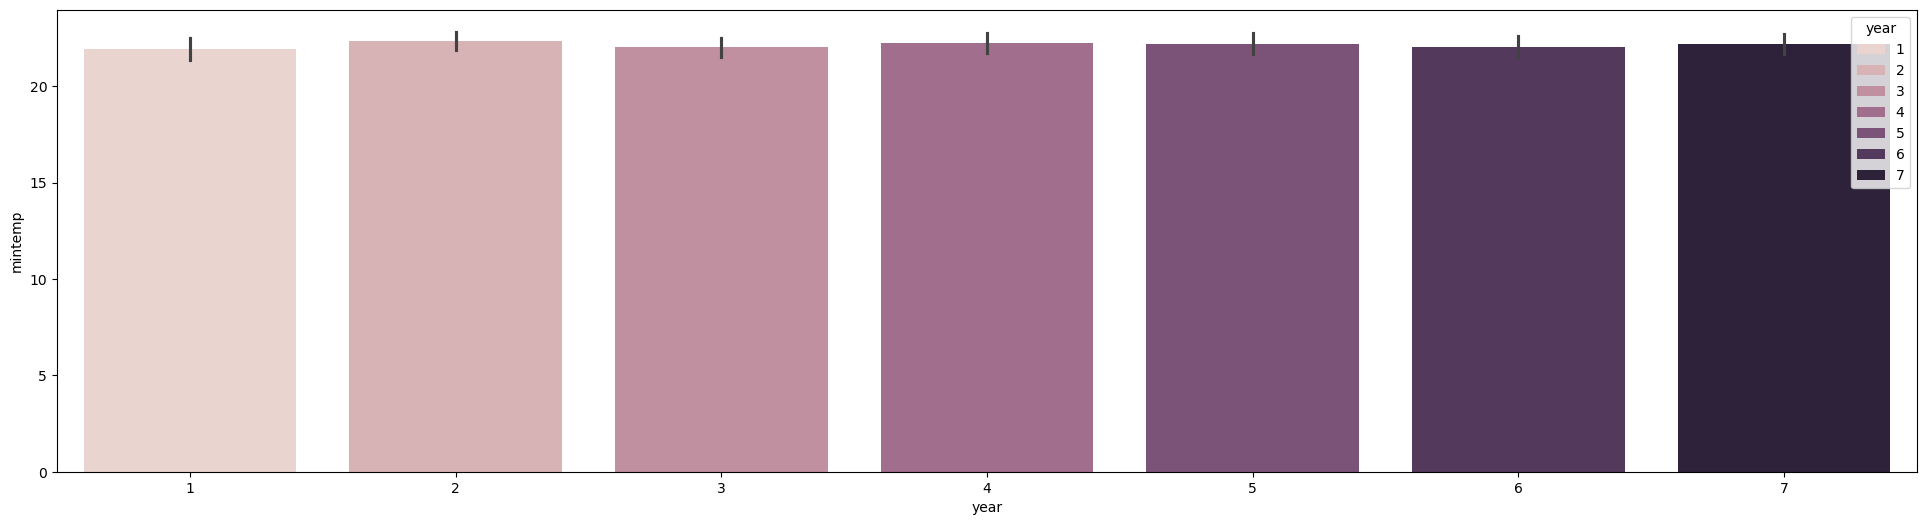

In [8]:
plt.figure(figsize=(24,6))
sns.barplot(y=rain_data.mintemp, x=rain_data.year, hue=rain_data.year)

In [9]:
for a in range(1,8):
    b = rain_data.loc[(rain_data.year == a ) & (rain_data.rainfall == 1)]
    print(b.shape)

(249, 12)
(265, 12)
(275, 12)
(272, 12)
(274, 12)
(276, 12)
(288, 12)


In [10]:
test_data["year"] = (test_data.index + 1) / 365
test_data["year"] = np.ceil(test_data.year)
test_data["year"] = test_data["year"] + 7
test_data = test_data.astype({'year': 'int64'})

In [11]:
rain_data["time"] = np.arange(len(rain_data.index))

In [12]:
rain_data

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,year,time
0,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,1,1,0
1,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,1,1
2,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,1,2
3,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,1,3
4,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2551,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1,7,2551
2552,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1,7,2552
2553,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1,7,2553
2554,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1,7,2554


In [13]:
test_data["time"] = np.arange(len(test_data.index)) + 2556

In [14]:
test_data

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,year,time
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,8,2556
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,8,2557
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,8,2558
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,8,2559
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,8,2560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,2915,361,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,9,3281
726,2916,362,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,9,3282
727,2917,363,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,9,3283
728,2918,364,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,9,3284


In [15]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.232838
sunshine         0.161076
humidity         0.130928
time             0.084347
dewpoint         0.033111
temparature      0.028568
maxtemp          0.026417
mintemp          0.012622
pressure         0.011168
year             0.008852
windspeed        0.004863
winddirection    0.000524
Name: MI Scores, dtype: float64

In [16]:
rain_data['Lag_1'] = rain_data['rainfall'].shift(1)
rain_data.dropna(inplace=True, ignore_index=True)
rain_data

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,year,time,Lag_1
0,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,1,1,1.0
1,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,1,2,1.0
2,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,1,3,1.0
3,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,1,4,1.0
4,1018.8,24.3,20.9,19.2,18.0,84.0,51.0,7.7,20.0,14.5,1,1,5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2550,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1,7,2551,1.0
2551,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1,7,2552,1.0
2552,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1,7,2553,1.0
2553,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1,7,2554,1.0


In [17]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall
X_test = test_data
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.223735
sunshine         0.171171
humidity         0.144695
time             0.079328
dewpoint         0.034495
temparature      0.032664
mintemp          0.025211
pressure         0.019750
Lag_1            0.019555
maxtemp          0.019153
winddirection    0.012898
year             0.005488
windspeed        0.001694
Name: MI Scores, dtype: float64

In [18]:
cols = ["cloud", "sunshine", "humidity", "time"]
cols_for_scaling = X.loc[:, cols]
cols_for_scaling

,cloud,sunshine,humidity,time
0,83.0,0.6,81.0,1
1,91.0,0.0,95.0,2
2,88.0,1.0,90.0,3
3,81.0,0.0,95.0,4
4,51.0,7.7,84.0,5
...,...,...,...,...
2550,88.0,0.1,97.0,2551
2551,88.0,0.0,91.0,2552
2552,79.0,5.0,79.0,2553
2553,93.0,0.1,92.0,2554


In [19]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X_scaled = ms.fit_transform(cols_for_scaling)
X_scaled = pd.DataFrame(X_scaled, columns=[cols])
X_test_scaled = ms.fit_transform(cols_for_scaling)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[cols])

X_scaled

,cloud,sunshine,humidity,time
0,0.83,0.049587,0.725806,0.000000
1,0.91,0.000000,0.951613,0.000392
2,0.88,0.082645,0.870968,0.000783
3,0.81,0.000000,0.951613,0.001175
4,0.51,0.636364,0.774194,0.001566
...,...,...,...,...
2550,0.88,0.008264,0.983871,0.998434
2551,0.88,0.000000,0.887097,0.998825
2552,0.79,0.413223,0.693548,0.999217
2553,0.93,0.008264,0.903226,0.999608


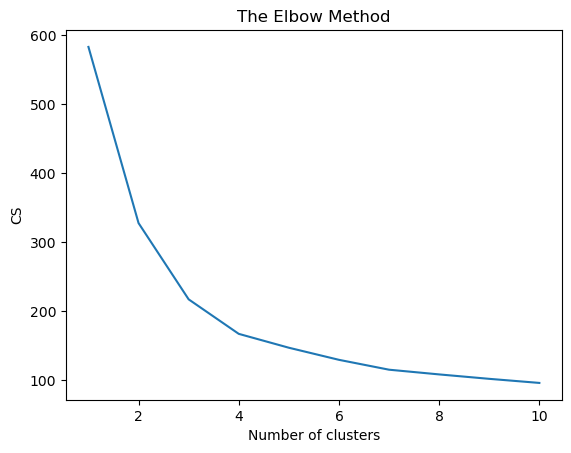

In [20]:
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_scaled)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [21]:
kmeans = KMeans(n_clusters=2, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 2008 out of 2555 samples were correctly labeled.
Accuracy score: 0.79


In [22]:
#cluster = kmeans.fit(X_scaled)
X_scaled["cluster"] = kmeans.predict(X_scaled)
kmeans.fit(X_test_scaled)
X_test_scaled["cluster"] = kmeans.predict(X_test_scaled)

In [23]:
X_cd = kmeans.fit_transform(X_scaled)
X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
X_test_cd = kmeans.fit_transform(X_test_scaled)
X_test_cd = pd.DataFrame(X_test_cd, columns=[f"Centroid_{i}" for i in range(X_test_cd.shape[1])])

In [24]:
X = X.join(X_cd)
X_test = X_test.join(X_test_cd)
X["cluster"] = X_scaled["cluster"]
X_test["cluster"] = X_test_scaled["cluster"]

In [25]:
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,year,time,Lag_1,Centroid_0,Centroid_1,cluster
0,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,1,1.0,1.310486,0.517622,1
1,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,2,1.0,1.385557,0.548167,1
2,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,3,1.0,1.322852,0.515949,1
3,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,4,1.0,1.363375,0.546868,1
4,1018.8,24.3,20.9,19.2,18.0,84.0,51.0,7.7,20.0,14.5,1,5,1.0,0.504191,1.284758,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2550,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,7,2551,1.0,1.392811,0.537612,1
2551,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,7,2552,1.0,1.376701,0.512908,1
2552,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,7,2553,1.0,1.181006,0.586252,1
2553,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,7,2554,1.0,1.388364,0.519835,1


In [26]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.204170
Centroid_1       0.175983
sunshine         0.161060
humidity         0.158629
Centroid_0       0.146879
cluster          0.112017
time             0.081878
maxtemp          0.027561
mintemp          0.024643
temparature      0.022156
dewpoint         0.019513
winddirection    0.008189
pressure         0.004555
Lag_1            0.003686
windspeed        0.000000
year             0.000000
Name: MI Scores, dtype: float64

In [27]:
score_dataset(X, y)

0.8930304623625315


In [28]:
X = X.drop(labels = ("year"), axis=1)
X_test = X_test.drop(labels = ("year"), axis=1)
score_dataset(X, y)

0.8930990616327577


In [29]:
X = X.drop(labels = ("windspeed"), axis=1)
X_test = X_test.drop(labels = ("windspeed"), axis=1)
score_dataset(X, y)

0.8929002834346875


In [30]:
X_test

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,time,Centroid_0,Centroid_1,cluster
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,2556,1.310486,0.517622,1
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,2557,1.385557,0.548167,1
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,2558,1.322852,0.515949,1
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,2559,1.363375,0.546868,1
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,2560,0.504191,1.284758,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,2915,361,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,3281,1.298008,0.282300,1
726,2916,362,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,3282,1.324939,0.313453,1
727,2917,363,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,3283,1.295416,0.276843,1
728,2918,364,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,3284,1.295012,0.311284,1


In [31]:
features = ["cloud", "cluster", "Centroid_1", "Centroid_0", "humidity", "sunshine", "temparature", "time", "humidity"]
Z = X.loc[:, features]
W = X_test.loc[:, features]
# `apply_pca`, defined above, reproduces the code from the tutorial
pca, X_pca, loadings = apply_pca(Z)
print(loadings)

                  PC1       PC2       PC3       PC4       PC5       PC6  \
cloud       -0.372618 -0.012501 -0.014305 -0.077582 -0.885605 -0.218002   
cluster     -0.401237  0.158694 -0.022911 -0.248838  0.286008 -0.347481   
Centroid_1   0.404896 -0.104060  0.031177  0.247814 -0.093204  0.142973   
Centroid_0  -0.398392  0.191714 -0.019701 -0.168825  0.312709 -0.121582   
humidity    -0.312993 -0.527469  0.071088  0.325480  0.112374 -0.012545   
sunshine     0.401060 -0.176111  0.001151  0.053411  0.044645 -0.882191   
temparature  0.142336 -0.581693 -0.087161 -0.780754 -0.001328  0.133869   
time        -0.021665 -0.035325 -0.990053  0.133580  0.013326  0.003500   
humidity    -0.312993 -0.527469  0.071088  0.325480  0.112374 -0.012545   

                  PC7       PC8           PC9  
cloud        0.151078 -0.011365  1.432894e-16  
cluster      0.012992 -0.740721  2.771850e-16  
Centroid_1   0.748909 -0.415758  2.729369e-17  
Centroid_0   0.640198  0.503208 -1.777650e-16  
humidity 

In [32]:
X = X.join(X_pca)
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,time,...,cluster,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,1,...,1,-1.314187,1.180527,1.732978,-0.033968,0.056314,0.147271,0.345588,-0.122596,2.458517e-16
1,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,2,...,1,-2.641977,-0.617783,1.960481,0.965246,0.102338,0.153205,0.571236,-0.112393,7.595402e-16
2,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,3,...,1,-2.025708,-0.183229,1.854173,0.410112,0.080073,0.004461,0.424127,-0.104737,-6.259761e-16
3,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,4,...,1,-2.385390,-0.774937,1.943284,0.808230,0.560402,0.311294,0.476275,-0.130731,-6.281785e-16
4,1018.8,24.3,20.9,19.2,18.0,84.0,51.0,7.7,20.0,5,...,0,2.172910,-0.606592,1.909481,1.389248,0.405959,0.047778,0.127871,0.118597,1.082633e-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2550,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,2551,...,1,-2.779861,-1.137933,-1.445863,1.399158,0.353824,0.197862,0.563638,-0.113529,-7.709935e-17
2551,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,2552,...,1,-2.427455,0.001773,-1.497908,1.401697,0.181971,0.153582,0.452700,-0.107021,4.042812e-17
2552,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,2553,...,1,-0.567249,1.321412,-1.668849,0.821143,0.183516,-0.851462,0.200135,-0.163981,5.849138e-17
2553,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,2554,...,1,-2.654202,0.099569,-1.452442,1.771762,-0.018826,0.013785,0.489824,-0.100271,-3.992814e-17


In [33]:
pca, X_pca, loadings = apply_pca(Z)
X_test = X_test.join(X_pca)

In [34]:
score_dataset(X, y)

0.8931140767678738


In [35]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.212776
PC1              0.206955
Centroid_1       0.175983
sunshine         0.175573
Centroid_0       0.146879
humidity         0.146647
cluster          0.130411
time             0.079531
PC5              0.075473
temparature      0.040426
pressure         0.030266
maxtemp          0.027525
PC8              0.024982
dewpoint         0.024214
PC6              0.020522
Lag_1            0.019507
PC2              0.017651
PC9              0.014955
PC3              0.014318
mintemp          0.012653
winddirection    0.006031
PC4              0.003592
PC7              0.000000
Name: MI Scores, dtype: float64

In [36]:
X = X.drop(labels = ("PC7"), axis=1)
X_test = X_test.drop(labels = ("PC7"), axis=1)
score_dataset(X, y)

0.8930781367496475


In [37]:
X = X.drop(labels = ("Lag_1"), axis=1)
#X_test = X_test.drop(labels = ("Lag_1"), axis=1)
score_dataset(X, y)

0.8919665744113789


In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=1,
    class_weight="balanced",
    solver="liblinear",
)
score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print(score.mean())

0.8911831725378827


In [39]:
%%time
from sklearn.model_selection import GridSearchCV
cross_valid_scores = {}
parameters = {
    "C": [0.001, 0.01, 0.1, 1.],
    "penalty": ["l1", "l2"]
}

model_logistic_regression = LogisticRegression(
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)

model_logistic_regression = GridSearchCV(
    model_logistic_regression, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_logistic_regression.fit(X, y)

print('-----')
print(f'Best parameters {model_logistic_regression.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + 
    f'{model_logistic_regression.best_score_:.3f}'
)
cross_valid_scores['logistic_regression'] = model_logistic_regression.best_score_
print('-----')

/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/sit

-----
Best parameters {'C': 0.01, 'penalty': 'l2'}
Mean cross-validated accuracy score of the best_estimator: 0.892
-----
CPU times: user 12.3 s, sys: 207 ms, total: 12.5 s
Wall time: 15.2 s


In [40]:
%%time
from sklearn.ensemble import RandomForestClassifier

# Parametr tuning GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
cross_valid_scores = {}

parameters = {
    "n_estimators": [5, 10, 15, 20, 25], 
    "max_depth": [3, 5, 7, 9, 11, 13],
}

model_random_forest = RandomForestClassifier(
    random_state=0,
    class_weight='balanced',
)

model_random_forest = GridSearchCV(
    model_random_forest, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_random_forest.fit(X, y)

print('-----')
print(f'Best parameters {model_random_forest.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + \
    f'{model_random_forest.best_score_:.3f}'
)
cross_valid_scores['desicion_tree'] = model_random_forest.best_score_
print('-----')

-----
Best parameters {'max_depth': 3, 'n_estimators': 15}
Mean cross-validated accuracy score of the best_estimator: 0.878
-----
CPU times: user 9.03 s, sys: 78.9 ms, total: 9.1 s
Wall time: 9.33 s


In [41]:
model_logistic_regression = LogisticRegression(C=1, penalty="l2",
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)

In [42]:
X_test.columns

Index(['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection', 'time',
       'Centroid_0', 'Centroid_1', 'cluster', 'PC1', 'PC2', 'PC3', 'PC4',
       'PC5', 'PC6', 'PC8', 'PC9'],
      dtype='object')

In [43]:
X.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'winddirection', 'time', 'Centroid_0',
       'Centroid_1', 'cluster', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6',
       'PC8', 'PC9'],
      dtype='object')

In [44]:
X_test = X_test.drop(labels = ("id"), axis=1)


In [45]:
X_test = X_test.drop(labels = ("day"), axis=1)


In [46]:
model_logistic_regression.fit(X, y)
rf_test_preds = model_logistic_regression.predict(X_test)

In [47]:
X_test["id"] = test_data["id"]
X_test["rainfall"] = rf_test_preds
X_test.to_csv('SubmissionTimeSeriesTimeLag2Cls.csv', columns=['id','rainfall'], index=False)